In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib import patches as pat
from matplotlib import transforms
from matplotlib.collections import PatchCollection
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from joblib import load
import re
import scipy.cluster.hierarchy as sch
from collections import defaultdict

# custom code
import figutils
sys.path.insert(
    0, os.path.abspath('../2021_07_31_custom_adjacency_regularization/'))
import sequence_logo
from quad_model import *
import kl
import force

from collections.abc import Iterable

%matplotlib inline

2022-04-18 14:31:37.532482: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64:/.singularity.d/libs
2022-04-18 14:31:37.532502: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
Matplotlib is building the font cache; this may take a moment.


In [3]:
plt.style.use('/home/ms7490/scratch/code/scratch/matplotlib/clean.mplstyle')

# Load data and models

In [4]:
xTr = load(f'../2021_07_31_custom_adjacency_regularization/data/xTr_ES7_HeLa_ABC.pkl')
yTr = load(f'../2021_07_31_custom_adjacency_regularization/data/yTr_ES7_HeLa_ABC.pkl')
xTe = load(f'../2021_07_31_custom_adjacency_regularization/data/xTe_ES7_HeLa_ABC.pkl')
yTe = load(f'../2021_07_31_custom_adjacency_regularization/data/yTe_ES7_HeLa_ABC.pkl')

In [5]:
model_fname = f'../2021_07_31_custom_adjacency_regularization/models/custom_adjacency_regularizer_20210731_124_step3.h5'
model = tf.keras.models.load_model(model_fname)

2022-04-18 14:31:50.731264: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2022-04-18 14:31:50.731291: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: gr061.hpc.nyu.edu
2022-04-18 14:31:50.731295: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: gr061.hpc.nyu.edu
2022-04-18 14:31:50.731423: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: Invalid argument: expected %d.%d, %d.%d.%d, or %d.%d.%d.%d form for driver version; got "1"
2022-04-18 14:31:50.731444: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 470.57.2
2022-04-18 14:31:50.731982: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operation

In [6]:
num_seq_filters = model.get_layer('qc_incl').kernel.shape[2]
num_struct_filters = model.get_layer('c_incl_struct').kernel.shape[2]

position_bias_size = model.get_layer('position_bias_incl').kernel.shape[0]
struct_filter_width = model.get_layer("c_incl_struct").kernel.shape[0]
input_length = model.input[0].shape[1]

# Visualize sequence filters

In [7]:
qc_incl = model.get_layer('qc_incl')
qc_skip = model.get_layer('qc_skip')

logo_dfs_incl_simple = figutils.compute_activations_simple_conv(qc_incl)
logo_dfs_skip_simple = figutils.compute_activations_simple_conv(qc_skip)

  0%|          | 0/20 [00:00<?, ?it/s]

findfont: Font family ['sans'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


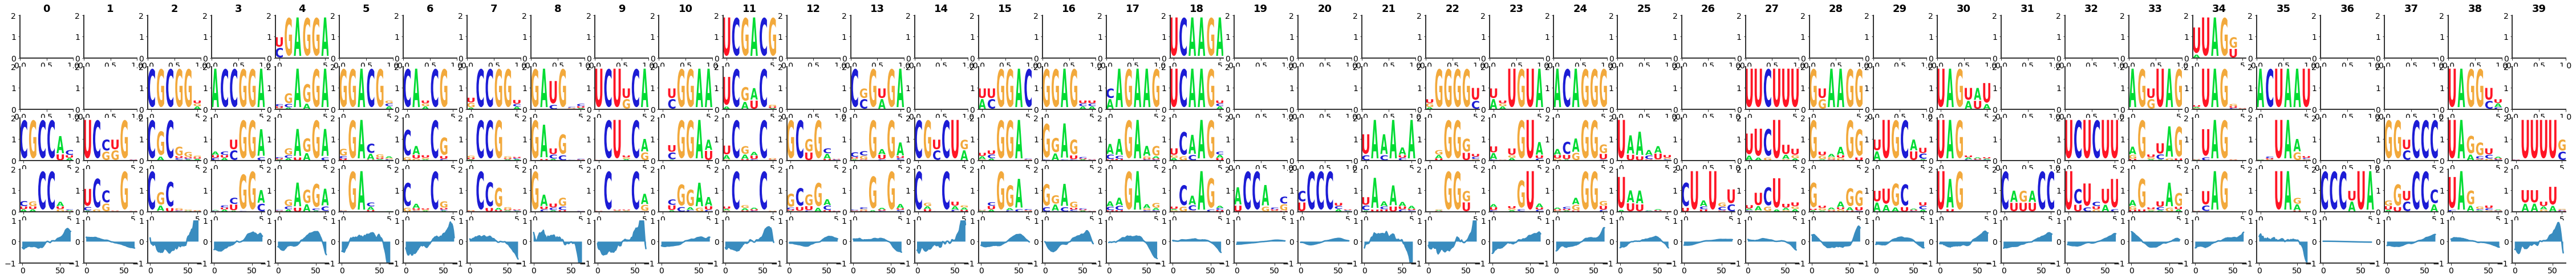

In [8]:
fig, axarr = plt.subplots(5, 2 * num_seq_filters, figsize=(80, 8), sharex=False, sharey=False)

for filter_num in tqdm(range(num_seq_filters), leave=False):
    axarr[0, filter_num].set_title(f'{filter_num}')
    axarr[0, num_seq_filters+filter_num].set_title(f'{num_seq_filters+filter_num}')
    df = logo_dfs_incl_simple[filter_num]
    sequence_logo.plot_logo(df, 6, axarr[0, filter_num])
    sequence_logo.plot_logo(df, 4, axarr[1, filter_num])
    sequence_logo.plot_logo(df, 2, axarr[2, filter_num])
    sequence_logo.plot_logo(df, 0, axarr[3, filter_num])
    
    df = logo_dfs_skip_simple[filter_num]
    sequence_logo.plot_logo(df, 6, axarr[0, num_seq_filters+filter_num])
    sequence_logo.plot_logo(df, 4, axarr[1, num_seq_filters+filter_num])
    sequence_logo.plot_logo(df, 2, axarr[2, num_seq_filters+filter_num])
    sequence_logo.plot_logo(df, 0, axarr[3, num_seq_filters+filter_num])
    
    for i in range(axarr.shape[1]):
        for j in range(4):
            axarr[j, i].set_ylim(0, 2)
    
for idx, row in enumerate(model.get_layer('position_bias_incl').kernel.numpy().T):
    axarr[4, idx].plot(range(position_bias_size-20), row[10:-10])
    axarr[4, idx].fill_between(range(position_bias_size-20), 0, row[10:-10])
    axarr[4, idx].set_ylim(-1, 1)
for idx, row in enumerate(model.get_layer('position_bias_skip').kernel.numpy().T):
    axarr[4, num_seq_filters+idx].plot(range(position_bias_size-20), row[10:-10])
    axarr[4, num_seq_filters+idx].fill_between(range(position_bias_size-20), 0, row[10:-10])
    axarr[4, num_seq_filters+idx].set_ylim(-1, 1)

# Group sequence filters

In [9]:
def get_membership_dict(ind):
    out = {}
    
    for i, group_i in enumerate(ind):
        if group_i not in out:
            out[group_i] = []
        out[group_i].append(i)
    return out

def get_fig_num_rows_cols(membership_dict):
    fig_rows = max([len(e) for e in list(membership_dict.values())])
    fig_cols = len(membership_dict.keys())
    return fig_rows, fig_cols 

In [10]:
structure_out_model = Model(inputs=model.inputs, outputs=[
    model.get_layer('activation_2').output,
    model.get_layer('activation_3').output
])

In [11]:
incl_act, skip_act = structure_out_model.predict(xTr, verbose=1)
incl_act_seq = incl_act[:, :, :num_seq_filters]
skip_act_seq = skip_act[:, :, :num_seq_filters]

  11/5996 [..............................] - ETA: 30s  

2022-04-18 14:32:16.109560: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


5996/5996 [==============================] - 30s 5ms/step


In [12]:
struct_acts = skip_act[:, :, num_seq_filters + np.array([0, 2, 3])].sum(axis=(1, 2))

In [13]:
np.random.seed(420)
high_struct_10 = np.random.choice(np.where(struct_acts > np.quantile(struct_acts, 0.95))[0], 10)
high_struct_10

array([ 88914,  92774,  52346,  23812,   5133, 181258,  73064,  32532,
       189093,  14034])

In [14]:
for e in figutils.oh_2_str(xTr[0][high_struct_10]):
    print(e)

CAUCCAGGUUAACAGUAACCACACCACAUCAUUCUGAUGUGGGACAGCCCACGUAAAUUCCGAGUUCGGAAUCUUGCGGACAGGUCUGAC
CAUCCAGGUUAUCGCGUGUUCGGGACUGUAGCUUAACACCCCGAACGCGCCGAAGAGGAGCGCUAUAGCCCGCUCCAAGGCAGGUCUGAC
CAUCCAGGUUCCCCGUAAGUGCUGCUUUCACUACAACACGGGAAGAUUUACAUAUCACCGUUGCUAUGACCUGUGCGCGACAGGUCUGAC
CAUCCAGGUUUAACAUCAGCCCGCACCGCCCCCCGGGCGAAGUGUUCCACUUGCCUCCAAAUACUAAACUCAAUGGAGAGCAGGUCUGAC
CAUCCAGGUUGCCACGCUUACACUACAUAUGAUCAUGCUACCCGUGACGGGUACCACAGCGAACCGCAGGCAUGCACGUCCAGGUCUGAC
CAUCCAGGUUCCUGGACCAGCUCGGAGCCACUUGGGCUUUGAGUUCCGUGCACCAUCGCUACUAGGAUUCUGUGUAACAGCAGGUCUGAC
CAUCCAGGUUUCCGUACCUACUACUGACCCUGGCCGCGGAUGUUCCCGCGCAGAACUCAAACUUAGAAGGUUGAAAGGCCCAGGUCUGAC
CAUCCAGGUUCAAGGGUGACGGAUCUGACUACACCAAACCCUAGGACCGUACACCGUCACAGGCCCCCUGGCCGUCAGUGCAGGUCUGAC
CAUCCAGGUUUUCCGAACUCUGAUAGAGUACCGUUCUGCGUACUCCCAGUUUGAUGCGAUGUCGGGCUUCCUGCGGUGCGCAGGUCUGAC
CAUCCAGGUUCAUGGAGGAGCCUCCGAUAAGUCUGCUAUCAGACGAAGGUAUUGCAUCGGCACAUUGUAACAAGGACCCUCAGGUCUGAC


In [15]:
incl_activations = dict()
skip_activations = dict()

tmp = (incl_act[:, 1:, :] + incl_act[:, :-1, :])
for k in tqdm(range(num_seq_filters)):
    a = tmp[:, :, k][:, 10:-10].max(axis=1).mean()
    incl_activations[k] = a

tmp = (skip_act[:, 1:, :] + skip_act[:, :-1, :])
for k in tqdm(range(num_seq_filters)):
    a = tmp[:, :, k][:, 10:-10].max(axis=1).mean()
    skip_activations[k] = a

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [16]:
incl_inds = sch.fcluster(sch.linkage(incl_act_seq.sum(axis=1).T,
                               metric='correlation',
                               method='complete'),
                   t=0.9,
                   criterion='distance')

skip_inds = sch.fcluster(sch.linkage(skip_act_seq.sum(axis=1).T,
                               metric='correlation',
                               method='complete'),
                   t=0.9,
                   criterion='distance')

Visualize grouped filters

In [17]:
incl_membership_dict = get_membership_dict(incl_inds)
skip_membership_dict = get_membership_dict(skip_inds)

  0%|          | 0/7 [00:00<?, ?it/s]

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


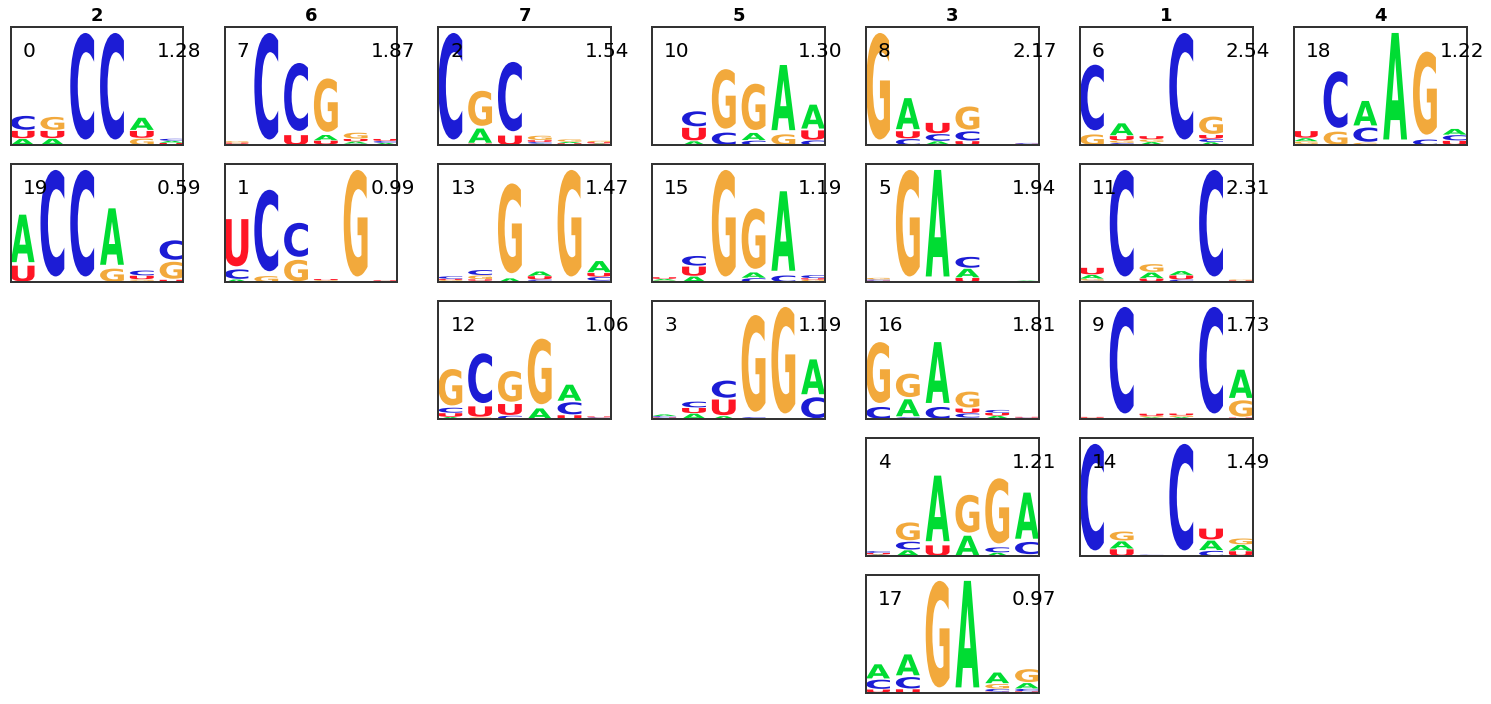

In [18]:
# incl filters
fig_rows, fig_cols = get_fig_num_rows_cols(incl_membership_dict)
fig, axarr = plt.subplots(fig_rows, fig_cols, figsize=[3 * fig_cols, 2 * fig_rows], sharex=True, sharey=True)

for ax in axarr.flatten():
    ax.axis('off')

for idx, mem_list_key in enumerate(tqdm(incl_membership_dict.keys())):
    mem_list = incl_membership_dict[mem_list_key]
    for jdx, filter_num in enumerate(sorted(mem_list, key=lambda x:-incl_activations[x])):
        axarr[jdx, idx].axis('on')
        df = logo_dfs_incl_simple[filter_num]
        act_thresh = 0 if df.query('activation > 0').shape[0] == 0 else 0
        sequence_logo.plot_logo(df, act_thresh, axarr[jdx, idx])
#         axarr[jdx, idx].set_title(f'filter {filter_num}')
        axarr[jdx, idx].spines['right'].set_visible(True)
        axarr[jdx, idx].spines['top'].set_visible(True)
        axarr[jdx, idx].set_xticks([])
        axarr[jdx, idx].set_yticks([])
        axarr[jdx, idx].text(0, 1.5, f'{filter_num}', fontsize=20)
        axarr[jdx, idx].text(4.5, 1.5, f'{incl_activations[filter_num]:.2f}', fontsize=20)
    axarr[0, idx].set_title(f'{mem_list_key}')
        

plt.tight_layout()
# fig.savefig(
#     './figs/incl_seq_filters_clustered.svg',
#     pad_inches=0.1,
#     bbox_inches='tight')
plt.show()

  0%|          | 0/6 [00:00<?, ?it/s]

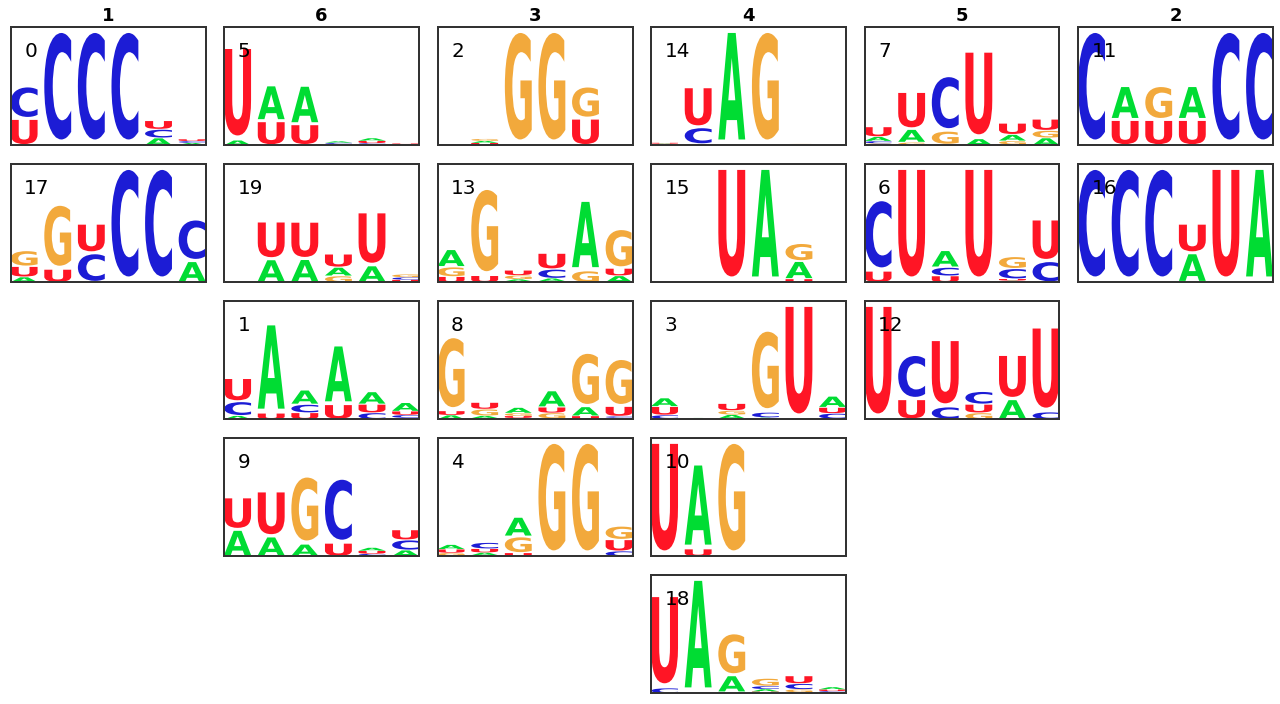

In [19]:
# skip filters
fig_rows, fig_cols = get_fig_num_rows_cols(skip_membership_dict)
fig, axarr = plt.subplots(fig_rows, fig_cols, figsize=[3 * fig_cols, 2 * fig_rows], sharex=True, sharey=True)

for ax in axarr.flatten():
    ax.axis('off')

for idx, mem_list_key in enumerate(tqdm(skip_membership_dict.keys())):
    mem_list = skip_membership_dict[mem_list_key]
    for jdx, filter_num in enumerate(sorted(mem_list, key=lambda x:-skip_activations[x])):
        axarr[jdx, idx].axis('on')
        df = logo_dfs_skip_simple[filter_num]
        act_thresh = 0 if df.query('activation > 0').shape[0] == 0 else 0
        sequence_logo.plot_logo(df, act_thresh, axarr[jdx, idx])
#         axarr[jdx, idx].set_title(f'filter {filter_num}')
        axarr[jdx, idx].spines['right'].set_visible(True)
        axarr[jdx, idx].spines['top'].set_visible(True)
        axarr[jdx, idx].set_xticks([])
        axarr[jdx, idx].set_yticks([])
        axarr[jdx, idx].text(0, 1.5, f'{filter_num}', fontsize=20)
    axarr[0, idx].set_title(f'{mem_list_key}')
        

plt.tight_layout()
# fig.savefig(
#     './figs/skip_seq_filters_clustered.svg',
#     pad_inches=0.1,
#     bbox_inches='tight')
plt.show()

# Dump representative sequence filters

Strategy: the representative is the one with highest mean activation

In [20]:
def get_representative_dict(membership_dict, activations):
    scores = activations.sum(axis=1).mean(axis=0)
    out = dict()
    
    for cluster_id in membership_dict:
        filter_ids = membership_dict[cluster_id]
        
        top_filter = np.argmax(scores[filter_ids])
        out[cluster_id] = filter_ids[top_filter]
    return out

In [21]:
incl_representative_dict = get_representative_dict(incl_membership_dict, incl_act_seq)
skip_representative_dict = get_representative_dict(skip_membership_dict, skip_act_seq)

Manually modify representatives

In [22]:
skip_representative_dict[4] = 10
# incl_representative_dict[7] = 3
incl_representative_dict[3] = 5

In [23]:
seq_filters_grouping = dict(incl_membership_dict=incl_membership_dict,
     skip_membership_dict=skip_membership_dict,
     incl_representative_dict=incl_representative_dict,
     skip_representative_dict=skip_representative_dict)
# dump(seq_filters_grouping, './data/seq_filters_grouping.pkl')

# Visualize structure filters

In [24]:
def extract_str_patches(lst, n):
    out = []
    for elem in lst:
        tmp = []
        n_elem = len(elem)
        assert n_elem >= n, f'{elem} is of length < n ({n})'
        for i in range(n_elem - n + 1):
            tmp.append(elem[i:i+n])
        out.append(tmp)
    return out

In [25]:
# structure filter properties to convert same padding to valid
left_struct_pad = (struct_filter_width - 1) // 2
right_struct_pad = struct_filter_width - 1 - left_struct_pad
struct_left_cutoff = left_struct_pad - 2
struct_right_cutoff = right_struct_pad - 3


In [26]:
# sns.histplot(skip_acts[..., num_seq_filters:].sum(axis=1)[:, 4], kde=True)
# sns.histplot(skip_acts[..., num_seq_filters:].sum(axis=1)[:, 1], color='r', kde=True)
# sns.histplot(skip_acts[..., num_seq_filters:].sum(axis=1)[:, [0, 2, 3]].sum(axis=1), color='g', kde=True)

# sns.histplot(skip_acts[..., [0, 17]].sum(axis=(1, 2)), color='purple', kde=True)

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


Iterating over k-mer list:   0%|          | 0/2864 [00:00<?, ?it/s]

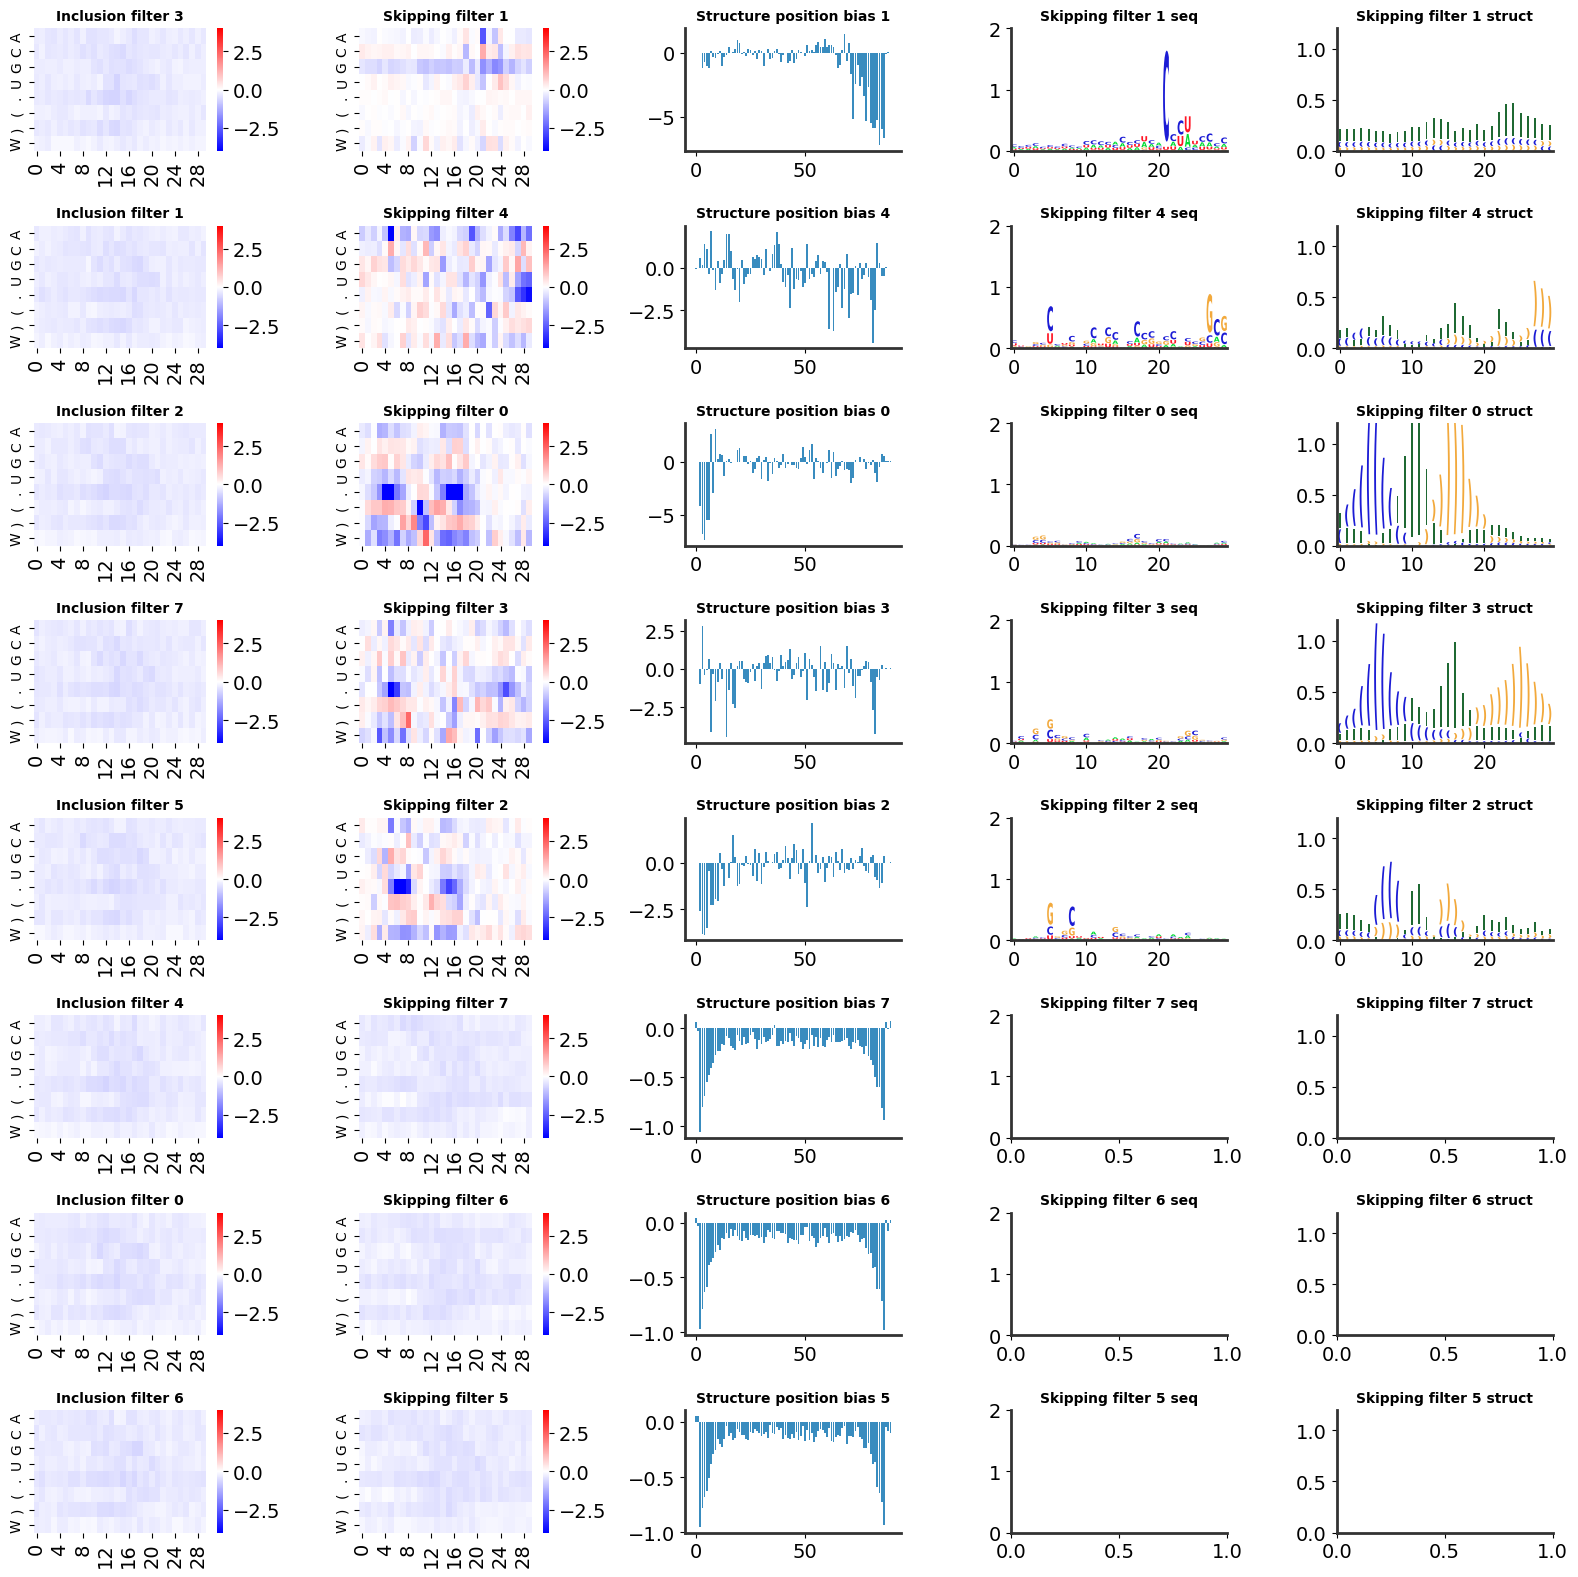

In [27]:
incl_conv_W, incl_conv_b = model.get_layer('c_incl_struct').weights
skip_conv_W, skip_conv_b = model.get_layer('c_skip_struct').weights

N = 1000
xTr_subset = [xTr[0][:N], xTr[1][:N], xTr[2][:N]]
incl_acts, skip_acts = structure_out_model.predict(xTr_subset, verbose=0, batch_size=20)

incl_order = np.argsort(incl_acts[..., num_seq_filters:].sum(axis=1).mean(axis=0))[::-1]
skip_order = np.argsort(skip_acts[..., num_seq_filters:].sum(axis=1).mean(axis=0))[::-1]

xTr_subset_nt = figutils.oh_2_str(xTr_subset[0], kind='seq')
A = extract_str_patches(xTr_subset_nt, struct_filter_width)
B = [(c, *d) for a, b in zip(
    A, skip_acts[:, struct_left_cutoff:-struct_right_cutoff, num_seq_filters:])
     for c, d in zip(a, b)]
acts_df = pd.DataFrame(B,
                       columns=['input'] +
                       [f'f{i}' for i in range(num_struct_filters)])

xTr_struct_subset_nt = figutils.oh_2_str(xTr_subset[1], kind='struct')
As = extract_str_patches(xTr_struct_subset_nt, struct_filter_width)
Bs = [(c, *d) for a, b in zip(
    As, skip_acts[:, struct_left_cutoff:-struct_right_cutoff,
                  num_seq_filters:]) for c, d in zip(a, b)]
acts_df_struct = pd.DataFrame(Bs,
                              columns=['input'] +
                              [f'f{i}' for i in range(num_struct_filters)])

fig, axarr = plt.subplots(num_struct_filters,
                          5,
                          figsize=(16, 16),
                          dpi=100,
                          sharex=False,
                          sharey=False)

M = model.get_layer('position_bias_skip_struct').kernel.numpy()
for i in range(num_struct_filters):
    sns.heatmap(incl_conv_W[..., incl_order[i]].numpy().T,
                cmap='bwr',
                ax=axarr[i, 0],
                vmin=-4,
                vmax=4)
    axarr[i, 0].set_yticks(np.arange(8) + 0.5)
    axarr[i, 0].set_yticklabels(("A", "C", "G", "U", ".", "(", ")", "W"),
                                fontsize=10)
    axarr[i, 0].set_title(f'Inclusion filter {incl_order[i]}', fontsize=10)

    sns.heatmap(skip_conv_W[..., skip_order[i]].numpy().T,
                cmap='bwr',
                ax=axarr[i, 1],
                vmin=-4,
                vmax=4)
    axarr[i, 1].set_yticks(np.arange(8) + 0.5)
    axarr[i, 1].set_yticklabels(("A", "C", "G", "U", ".", "(", ")", "W"),
                                fontsize=10)
    axarr[i, 1].set_title(f'Skipping filter {skip_order[i]}', fontsize=10)
    
    axarr[i, 2].bar(range(input_length), M[:, skip_order[i]])
    axarr[i, 2].set_title(f'Structure position bias {skip_order[i]}', fontsize=10)
    
    df = acts_df[['input', f'f{skip_order[i]}']]
    df.columns = ['input', 'activation']
    df = df.reset_index()
    sequence_logo.plot_logo(df, 2, axarr[i, 3])
    axarr[i, 3].set_ylim(0, 2)
    axarr[i, 3].set_title(f'Skipping filter {skip_order[i]} seq', fontsize=10)
    
    dfS = acts_df_struct[['input', f'f{skip_order[i]}']]
    dfS.columns = ['input', 'activation']
    dfS = dfS.reset_index(drop=True)
    sequence_logo.plot_logo(dfS, 1, axarr[i, 4], nts=['.', '(', ')'], color_map={".": "#1f6933", "(": "#1c1cd5", ")": "#f2a93c"})
    axarr[i, 4].set_ylim(0, 1.2)
    axarr[i, 4].set_title(f'Skipping filter {skip_order[i]} struct', fontsize=10)
    

plt.tight_layout()

# Group structure filters and dump representatives

In [28]:
incl_membership_struct_dict = {1: np.array([0, 1, 2, 3, 4, 5, 6, 7])}
skip_membership_struct_dict = {1: np.array([1]), 2: np.array(
    [0, 2, 3]), 3: np.array([5, 6, 7]), 4: np.array([4])}
incl_representative_struct_dict = {1: 0}
skip_representative_struct_dict = {1: 1, 2: 0, 3: 5}

struct_filters_grouping = dict(incl_membership_dict=incl_membership_struct_dict,
     skip_membership_dict=skip_membership_struct_dict,
     incl_representative_dict=incl_representative_struct_dict,
     skip_representative_dict=skip_representative_struct_dict)

# dump(struct_filters_grouping, './data/struct_filters_grouping.pkl')

# Make table of representative filters

- For each exon, each filter group: compute total activation per group
- Compute 90th percentile of each groups activations

TODO: add structure and PORG (POoR in G filter)

In [29]:
incl_color = '#669aff'
skip_color = '#ff6666'
light_incl_color = '#C5D6FB'
light_skip_color = '#F6C3C2'

In [30]:
incl_membership_scores = {
    key: np.quantile(incl_act_seq[:, :, incl_membership_dict[key]].sum(axis=(1, 2)), 0.9)
    for key in incl_membership_dict.keys()
}
skip_membership_scores = {
    key: np.quantile(skip_act_seq[:, :, skip_membership_dict[key]].sum(axis=(1, 2)), 0.9)
    for key in skip_membership_dict.keys()
}

In [31]:
incl_plot_order = sorted(incl_membership_scores, key=lambda x: -incl_membership_scores[x])
skip_plot_order = sorted(skip_membership_scores, key=lambda x: -skip_membership_scores[x])

In [32]:
def all_above_x(arr, x):
    return arr[arr > x]

def all_above_x(arr, x):
    return arr[(arr > np.quantile(arr, x[0])) * (arr < np.quantile(arr, x[1]))]

In [33]:
def index_above_quantile(arr, q):
    return arr > np.quantile(arr, q)

In [34]:
from scipy.ndimage import gaussian_filter1d

In [35]:
def draw_number(ax, number, color, set_xlimits=False):
    ax.text(-1.5, 1, f"{number}", color='k',
            fontweight='normal', ha='center', va='center', fontsize=15,
            bbox={"boxstyle": "circle", "facecolor": color, "linewidth": 1, 'edgecolor': 'k'})
    if set_xlimits:
        ax.set_xlim(-0.5, 5.5)
        ax.set_ylim(0,  2)

In [36]:
def draw_numbered_text(ax, number, text, color, set_xlimits=False):
    ax.text(0.5, 0.5, s=text, fontsize=15,
            transform=ax.transAxes, ha='center', va='center')
    draw_number(ax, number, color, set_xlimits)

In [37]:
def plot_logo(ax, df, num_idx, color):
    act_thresh = 0 if df.query('activation > 0').shape[0] == 0 else 0
    sequence_logo.plot_logo(df, act_thresh, ax)
    draw_number(ax, num_idx+1, color)
    ax.set_xlim(-0.5, 5.5)
    ax.set_ylim(0,  2)

In [38]:
def get_position_slope(activations_tensor, quantile_threshold):
    tt = index_above_quantile(activations_tensor.sum(axis=(1,2)), quantile_threshold)
    slope = activations_tensor.sum(axis=2)[tt].mean(axis=0)[10:-10]
    return slope

In [39]:
def plot_slope(ax, slope, color):
    ax.plot(
        range(len(slope)), slope, color='#868686', linewidth=2, clip_on=False)
    ax.fill_between(
        range(len(slope)), 0, slope, color=color)
    ax.set_xlim(0, len(slope))
    ax.set_ylim(0, 1.1)
    
    # add thin line around plot
    ax.plot([0, 0, len(slope), len(slope)],
                                          [slope[0], 0, 0, slope[-1]],
                                          color='#868686', linewidth=2,
                                          clip_on=False
                                         )

In [40]:
def get_and_plot_slope(ax, activations_tensor, quantile_threshold, color, smooth=False, draw_yaxis=False):
    slope = get_position_slope(activations_tensor, quantile_threshold)
    if smooth:
        slope = gaussian_filter1d(slope, 1)
    plot_slope(ax, slope, color)
    
    if draw_yaxis:
        ax.axis('on')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(True)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)

In [41]:
top_k = 4
num_extra_filters = 2

In [42]:
incl_motif_j = 0
incl_position_bias_j = 1
skip_motif_j = 2
skip_position_bias_j = 3

In [43]:
activation_quantile_threshold = 0.95

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


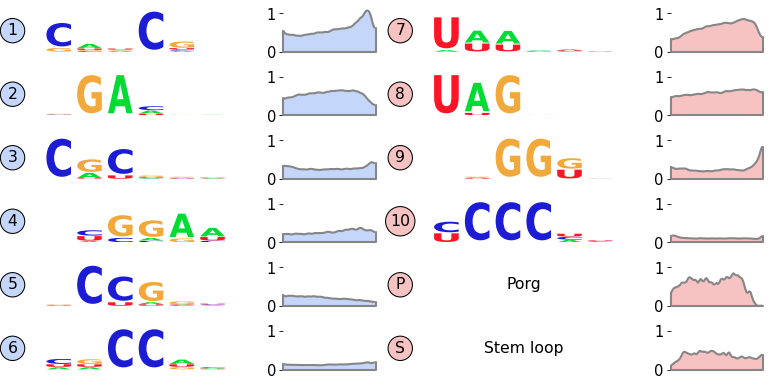

In [44]:
fig, axarr = plt.subplots(top_k + num_extra_filters, 4, figsize=(
    12, 1 * (top_k + num_extra_filters)), sharex=False, sharey=False,
                          dpi=75, gridspec_kw={'width_ratios': [2, 1, 2, 1]})

for axrow in axarr:
    for ax in axrow:
        ax.axis('off')

special_skip_numbers = {top_k:'P', (top_k+1):'S'}
special_skip_text = {top_k:'Porg', (top_k+1):'Stem loop'}
special_skip_filters = {top_k:[1], (top_k+1):[0,2,3]}

for idx in range(top_k + num_extra_filters):
    # inclusion
    incl_key = incl_plot_order[idx]
    incl_filter_num = incl_representative_dict[incl_key]
    incl_df = logo_dfs_incl_simple[incl_filter_num]
    
    plot_logo(axarr[idx, incl_motif_j], incl_df, idx, light_incl_color)
    get_and_plot_slope(axarr[idx, incl_position_bias_j],
                       incl_act_seq[:, :, incl_membership_dict[incl_key]],
                       activation_quantile_threshold,
                       light_incl_color, smooth=True,
                       draw_yaxis=True
                      )
    
    # skipping
    if idx < top_k:
        skip_key = skip_plot_order[idx]
        skip_filter_num = skip_representative_dict[skip_key]
        skip_df = logo_dfs_skip_simple[skip_filter_num]
        # offset the skipping motifs' index by top_k + num_extra_filters
        plot_logo(axarr[idx, skip_motif_j], skip_df, idx + top_k + num_extra_filters, light_skip_color)
        
        skip_acts_tensor = skip_act_seq[:, :, skip_membership_dict[skip_key]]
    else:
        draw_numbered_text(axarr[idx, skip_motif_j], special_skip_numbers[idx], special_skip_text[idx],
                           light_skip_color, set_xlimits=True)
        skip_acts_tensor = skip_act[:, :, num_seq_filters:][:, :, special_skip_filters[idx]]
        
    get_and_plot_slope(axarr[idx, skip_position_bias_j],
                       skip_acts_tensor,
                       activation_quantile_threshold,
                       light_skip_color,
                       smooth=True,
                       draw_yaxis=True
                      )
        

    

        
fig.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.5)

# fig.savefig('./figs/representative_filters.svg',
#             transparent=True, pad_inches='tight')
# fig.savefig('./figs/representative_filters.pdf',
#             transparent=True, pad_inches='tight')

# Force plots

## Prerequisites

In [45]:
incl_filter_lookup = {}
for key, value in seq_filters_grouping['incl_membership_dict'].items():
    incl_filter_lookup[f'incl_seq_' + '_'.join(map(str, sorted(value)))] = incl_plot_order.index(key) + 1
for key, value in struct_filters_grouping['incl_membership_dict'].items():
    incl_filter_lookup[f'incl_struct_' + '_'.join(map(str, sorted(value)))] = incl_plot_order.index(key) + 1
    
skip_filter_lookup = {}
for key, value in seq_filters_grouping['skip_membership_dict'].items():
    skip_filter_lookup[f'skip_seq_' + '_'.join(map(str, sorted(value)))] = skip_plot_order.index(key) + 1
for key, value in struct_filters_grouping['skip_membership_dict'].items():
    skip_filter_lookup[f'skip_struct_' + '_'.join(map(str, sorted(value)))] = skip_plot_order.index(key) + 1

In [46]:
# Manually add Borg and structure and inclusion bias
skip_filter_lookup['skip_struct_0_2_3'] = 'S'
skip_filter_lookup['skip_struct_1'] = 'P'
skip_filter_lookup['skip_struct_5_6_7'] = '.'
incl_filter_lookup['incl_bias'] = 'B'
skip_filter_lookup['skip_struct_4'] = ' '

In [47]:
# Manually relabel skipping filters
skip_filter_lookup
for idx in range(len(skip_plot_order)):
    skip_key = skip_plot_order[idx]
    skip_filter_num = skip_representative_dict[skip_key]
    skip_filter_group = [b for a,b in list(seq_filters_grouping['skip_membership_dict'].items()) if skip_filter_num in b][0]
    key = f'skip_seq_' + '_'.join(map(str, sorted(skip_filter_group)))
    
    skip_filter_lookup[key] = idx + 1 + top_k + num_extra_filters
    print(key, skip_filter_lookup[key])

skip_seq_1_5_9_19 7
skip_seq_3_10_14_15_18 8
skip_seq_2_4_8_13 9
skip_seq_0_17 10
skip_seq_6_7_12 11
skip_seq_11_16 12


In [48]:
link_input = Input(shape=(1,))
w = model.get_layer('energy_seq_struct').w.numpy()
b = model.get_layer('energy_seq_struct').b.numpy()
link_output = model.get_layer('output_activation')(model.get_layer('gen_func')(w*link_input + b))
link_function = Model(inputs=link_input, outputs=link_output)

In [49]:
link_midpoint = force.get_link_midpoint(link_function)

## Plot tuner function

In [50]:
xs = np.linspace(-40, 40, 100)
ys = link_function(link_midpoint+xs[:, None]).numpy().flatten()

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


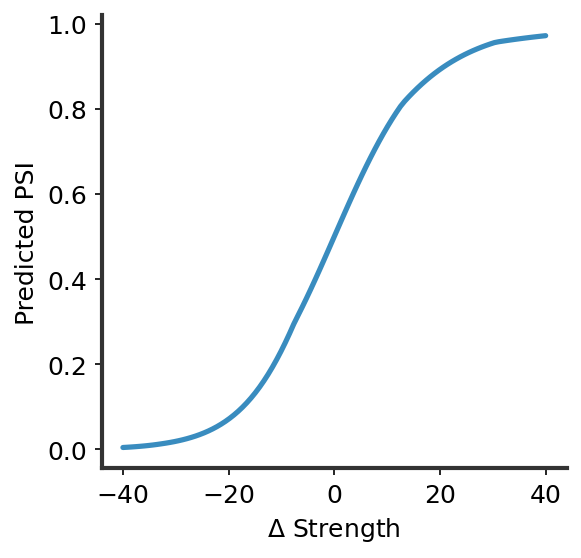

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=150)
# ax.text(0.5, 0.5, 'TODO')
ax.plot(xs, ys)
ax.set_ylabel('Predicted PSI', fontsize=12)
ax.set_xlabel('$\Delta$ Strength', fontsize=12)
ax.tick_params(axis='both', labelsize=12)

# fig.savefig('./figs/tuner.svg', pad_inches=0.1,
#     bbox_inches='tight')
# fig.savefig('./figs/tuner.pdf', pad_inches=0.1,
#     bbox_inches='tight')


## Multiple force plots

In [52]:
def draw_force_plot(data_incl_act, data_skip_act,
                    annotations,
                    seq_filters_grouping, struct_filters_grouping,
                    num_seq_filters, link_midpoint, highlight_forces,
                    incl_color, skip_color, light_incl_color, light_skip_color,
                    figsize=(40/2, 10/2), force_y_range=(0, 90), delta_force_y_range=(-15, 25),
                    ys = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.98, 0.986],
                    draw_numbers=False,
                    numbers_min_bar_height=4
                   ):
    assert data_incl_act.shape == data_skip_act.shape

    N = data_incl_act.shape[0]
    fig, axarr = plt.subplots(1, 3, figsize=figsize, dpi=150, gridspec_kw={'width_ratios': [2, 1, 2]})

    for idx in range(N):
        incl_act = data_incl_act[idx]
        skip_act = data_skip_act[idx]

        incl_forces, skip_forces = force.create_force_data(incl_act, skip_act,
                                                           seq_filters_grouping, struct_filters_grouping,
                                                           num_seq_filters, sum_positions=True, link_midpoint=link_midpoint)
        
        incl_forces = force.merge_small_forces(
            incl_forces, threshold=0).sort_values(ascending=False)
        skip_forces = force.merge_small_forces(
            skip_forces, threshold=0).sort_values(ascending=False)
        
        total_i = 0
        total_s = 0
        for (f_i_name, f_i), (f_s_name, f_s) in zip(incl_forces.items(), skip_forces.items()):
            if f_i_name in highlight_forces:
                f_i_color = incl_color
            else:
                f_i_color = light_incl_color
            if f_s_name in highlight_forces:
                f_s_color = skip_color
            else:
                f_s_color = light_skip_color

            axarr[0].bar([3*idx], [f_i], bottom=[total_i], color=f_i_color,
                         linewidth=1, edgecolor='#6b6b6b', width=1, zorder=2)
            total_i += f_i
            axarr[0].bar([3*idx+1], [f_s], bottom=[total_s],
                         color=f_s_color, linewidth=1, edgecolor='#6b6b6b', width=1, zorder=2)
            total_s += f_s
            
            # draw numbers
            if draw_numbers:
                labels_i = [incl_filter_lookup[e] for e in f_i_name.split("___")]
                labels_s = [skip_filter_lookup[e] for e in f_s_name.split("___")]
                
                if f_i > numbers_min_bar_height:
                    axarr[0].text(3*idx, total_i - f_i/2, labels_i[0], ha='center', va='center')
                if f_s > numbers_min_bar_height:
                    axarr[0].text(3*idx + 1, total_s - f_s/2, labels_s[0], ha='center', va='center')
            
            
            
        delta_force = incl_forces.sum() - skip_forces.sum()
        axarr[1].bar([3*idx + 0.5], [delta_force], color=light_skip_color if delta_force <
                     0 else light_incl_color, linewidth=1, edgecolor='#6b6b6b', width=2, zorder=2)


    axarr[0].set_ylim(*force_y_range)
    axarr[0].set_yticks(10 * np.unique(np.arange(force_y_range[1] + 1 if force_y_range[1] % 10 == 0 else force_y_range[1]) // 10))

    axarr[1].set_ylim(*delta_force_y_range)


    axarr[0].grid(axis='y', which='both', zorder=0)
    axarr[1].grid(axis='y', which='both', zorder=0)
    xmin, xmax = axarr[1].get_xlim()
    axarr[1].hlines(0, xmin, xmax, color='k', zorder=3, linewidth=1)
    axarr[1].set_xlim(xmin, xmax)


    axarr[0].set_ylabel('Strength')
    axarr[1].set_ylabel('$\Delta$ Strength')
    axarr[0].spines['right'].set_visible(True)

    axarr[0].set_xticks([3*i + 0.5 for i,_ in enumerate(annotations)])
    axarr[0].set_xticklabels([annotations[i] for i,_ in enumerate(annotations)])

    axarr[1].set_xticks([3*i + 0.5 for i,_ in enumerate(annotations)])
    axarr[1].set_xticklabels([annotations[i] for i,_ in enumerate(annotations)])

    
    xs = [force.get_link_midpoint(link_function, midpoint=m)-link_midpoint for m in ys]
    ys = [np.round(e, 2) for e in ys]

    ax2 = axarr[1].twinx()
    axarr[1].spines['right'].set_visible(True)

    ax2.set_yticks(xs)
    ax2.set_yticklabels(ys)
    ax2.set_ylim(*delta_force_y_range)
    ax2.set_ylabel('Predicted PSI')
    
    for ax in axarr:
        ax.tick_params(axis='both', labelsize=12)

    fig.tight_layout()
    
    return axarr, fig

### Structure force plots

In [53]:
# structure_exons = ['GAGTCCCGCTTACCATTGCATTTAAGAAAGCGGCCATACGCCGCTAAGACCCTACTCTTCAGAATACCAG',
#                    'GAGTCCCGCTTACCATTGCATTTAAGAAAGCGGCCATACGCCTCTAAGACCCTACTCTTCAGAATACCAG',
# 'GAGTCCCGCTTACCATTGCATTTAAGAAAGAGGCCATACGCCGCTAAGACCCTACTCTTCAGAATACCAG',
# 'GAGTCCCGCTTACCATTGCATTTAAGAAAGAGGCCATACGCCTCTAAGACCCTACTCTTCAGAATACCAG',]
structure_exons = [
    'GAGTCCCGCTTACCATTGCATTTAAGAAAGCGGCCATACGCCGCTAAGACCCTACTCTTCAGAATACCAG',
    'GAGTCCCGCTTACCATTGCATTTAAGAAAGAGGCCATACGCCGCTAAGACCCTACTCTTCAGAATACCAG',
    'GAGTCCCGCTTACCATTGCATTTAAGAAAGCGGCCATACGCCTCTAAGACCCTACTCTTCAGAATACCAG',
    'GAGTCCCGCTTACCATTGCATTTAAGAAAGAGGCCATACGCCTCTAAGACCCTACTCTTCAGAATACCAG'
]
annotations = ['O', 'D', 'U', 'B']

structure_sequences = [
    figutils.add_flanking(e, 10) for e in structure_exons
]
structure_data = figutils.create_input_data(structure_sequences)
structure_incl_act, structure_skip_act = structure_out_model.predict(structure_data)

highlight_forces=['skip_struct_0_2_3']

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


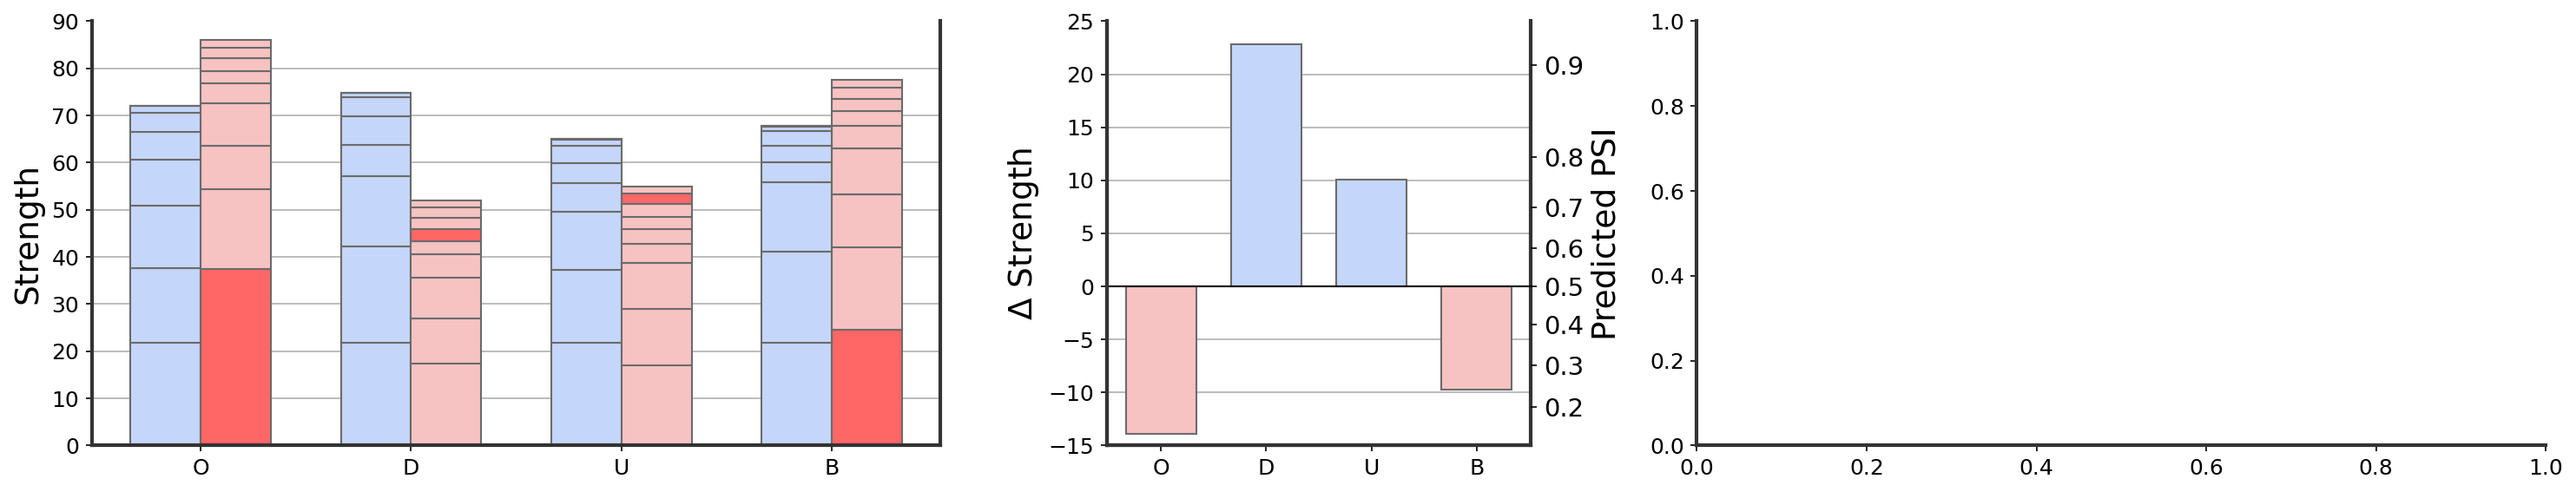

In [54]:
axarr, fig = draw_force_plot(structure_incl_act, structure_skip_act,
                             annotations,
                             seq_filters_grouping, struct_filters_grouping,
                             num_seq_filters, link_midpoint, highlight_forces,
                             incl_color, skip_color, light_incl_color, light_skip_color, figsize=(20, 4))

# fig.savefig('./figs/structure_experiment_forces.svg',
#             transparent=True, pad_inches=0.1,
#     bbox_inches='tight')
# fig.savefig('./figs/structure_experiment_forces.pdf',
#             transparent=True, pad_inches=0.1,
#     bbox_inches='tight')

### Porg force plots

In [55]:
# porg_exons = ['GACTATGAGCCCCAACGAACAAGCTCCTATCTGGGAACTCTTTTCTGCAGACTTTAACCCTACCCCCAGA',
# 'GACTATGAGCCCCAACGAACAAGCTCCTATCTGGGAACTCTTTTCTGCAGACTTTAAGCCTACCCCCAGA']
porg_exons = [
    'GTGCTACCTCACATTCAAGTATTCGCTCACCCCGGCGGCGAAATAAACACACTCATTAATGCCTGAAAGA',
    'CTCCCAGTCACACGCAGTCTCCGCCTAACTTCATAGTCTCATGTCATATCTTCTTAAGCTGCCGTGCCAC'
]
annotations = ['O', 'G']

porg_sequences = [
    figutils.add_flanking(e, 10) for e in porg_exons
]
porg_data = figutils.create_input_data(porg_sequences)
porg_incl_act, porg_skip_act = structure_out_model.predict(porg_data)

highlight_forces = ['skip_struct_1']

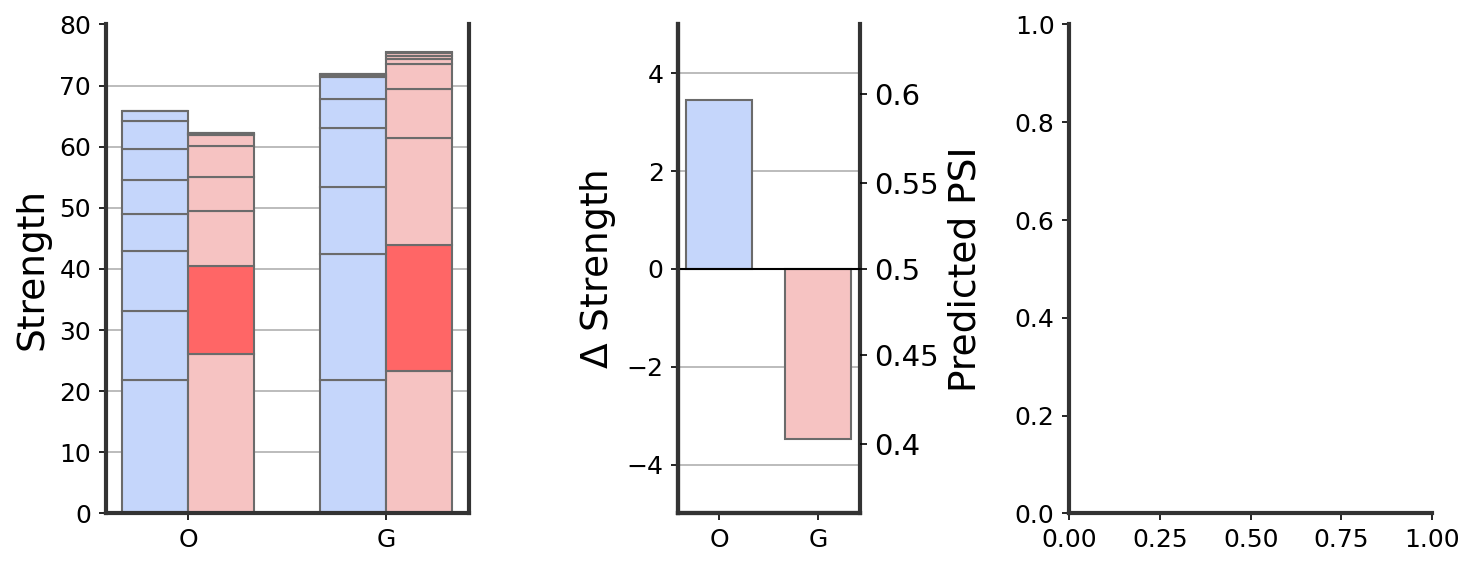

In [56]:
axarr, fig = draw_force_plot(porg_incl_act, porg_skip_act,
                             annotations,
                             seq_filters_grouping, struct_filters_grouping,
                             num_seq_filters, link_midpoint, highlight_forces,
                             incl_color, skip_color, light_incl_color, light_skip_color, figsize=(10, 4), 
                             delta_force_y_range=(-5, 5), force_y_range=(0, 80),
                             ys=[0.4, 0.45, 0.5, 0.55, 0.6]
                            )

# fig.savefig('./figs/porg_experiment_forces.svg',
#             transparent=True, pad_inches=0.1,
#     bbox_inches='tight')
# fig.savefig('./figs/porg_experiment_forces.pdf',
#             transparent=True, pad_inches=0.1,
#     bbox_inches='tight')

### Inclusion/exclusion force plot

In [57]:
incl_skip_exons = ['GCCCGAAAGCTCCCTACTGCAGTTTACGACCCTTAAGGCTTGGGTGCTCTTACGCGCTGATCGATATAAG',
'TCGCACCGCAGGTTCGGTTTTTTGGTATAATACGCGGCACTCCAAAATTACTCTGGGGCACCCTCACCAG']
annotations = ['E1', 'E2']

incl_skip_sequences = [
    figutils.add_flanking(e, 10) for e in incl_skip_exons
]
incl_skip_data = figutils.create_input_data(incl_skip_sequences)
incl_skip_incl_act, incl_skip_skip_act = structure_out_model.predict(incl_skip_data)
highlight_forces = []

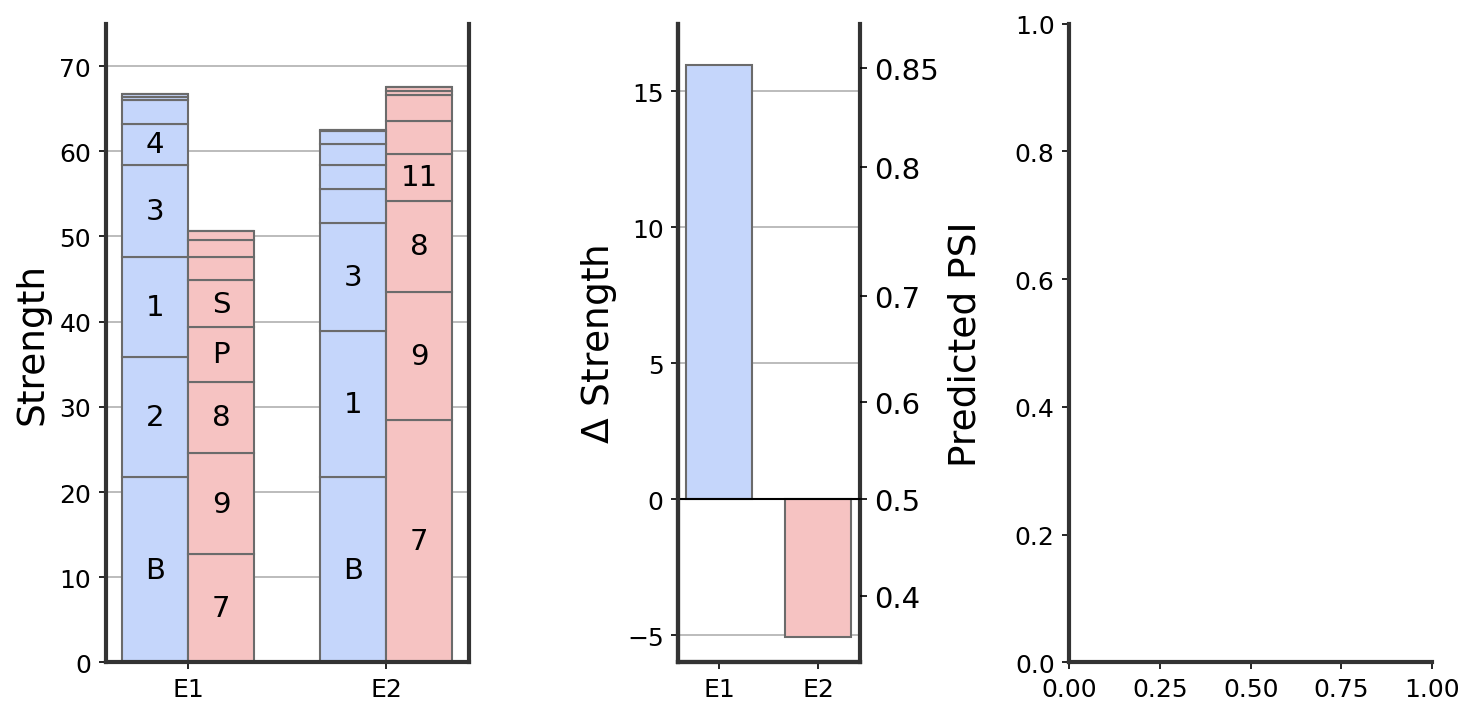

In [58]:
axarr, fig = draw_force_plot(incl_skip_incl_act, incl_skip_skip_act,
                             annotations,
                             seq_filters_grouping, struct_filters_grouping,
                             num_seq_filters, link_midpoint, highlight_forces,
                             incl_color, skip_color, light_incl_color, light_skip_color, figsize=(10, 5), 
                             delta_force_y_range=(-6, 17.5), force_y_range=(0, 75),
                             ys=[0.4, 0.5, 0.6, 0.7, 0.8, 0.85],
                             draw_numbers=True
                            )

# fig.savefig('./figs/incl_skip_forces.svg',
#             transparent=True, pad_inches=0.1,
#     bbox_inches='tight')
# fig.savefig('./figs/incl_skip_forces.pdf',
#             transparent=True, pad_inches=0.1,
#     bbox_inches='tight')

In [59]:
# pd.DataFrame([pd.concat(force.create_force_data(iA, sA,
#                                   seq_filters_grouping, struct_filters_grouping,
#                                   num_seq_filters, sum_positions=True, link_midpoint=link_midpoint))
# for iA, sA in zip(incl_skip_incl_act, incl_skip_skip_act)]).to_csv('./data/force_data/inclusion_skipping_example.csv')

## c4, c3, c2, c8

In [60]:
structure_exons = ['GCGGCACCTACTACAATGTCCCCCGCTGCATACACTCGGAGCCAATAGGGCGCCTATAGAGTGTAGTCCT',
                   'TCGCACCGCAGGTTCGGTTTTTTGGTATAATACGCGGCACTCCAAAATTACTCTGGGGCACCCTCACCAG',
                   'GCCCGAAAGCTCCCTACTGCAGTTTACGACCCTTAAGGCTTGGGTGCTCTTACGCGCTGATCGATATAAG',
                   'GGTGTCCCCCACTATCGACCTCATCAGTAATCAATCCGAGCGACCGCCTCATCCCAAAGGCACACGTCCA', ]
annotations = ['c4', 'c3', 'c2', 'c8']

structure_sequences = [
    figutils.add_flanking(e, 10) for e in structure_exons
]
structure_data = figutils.create_input_data(structure_sequences)
structure_incl_act, structure_skip_act = structure_out_model.predict(
    structure_data)

highlight_forces = []  # ['skip_struct_0_2_3']

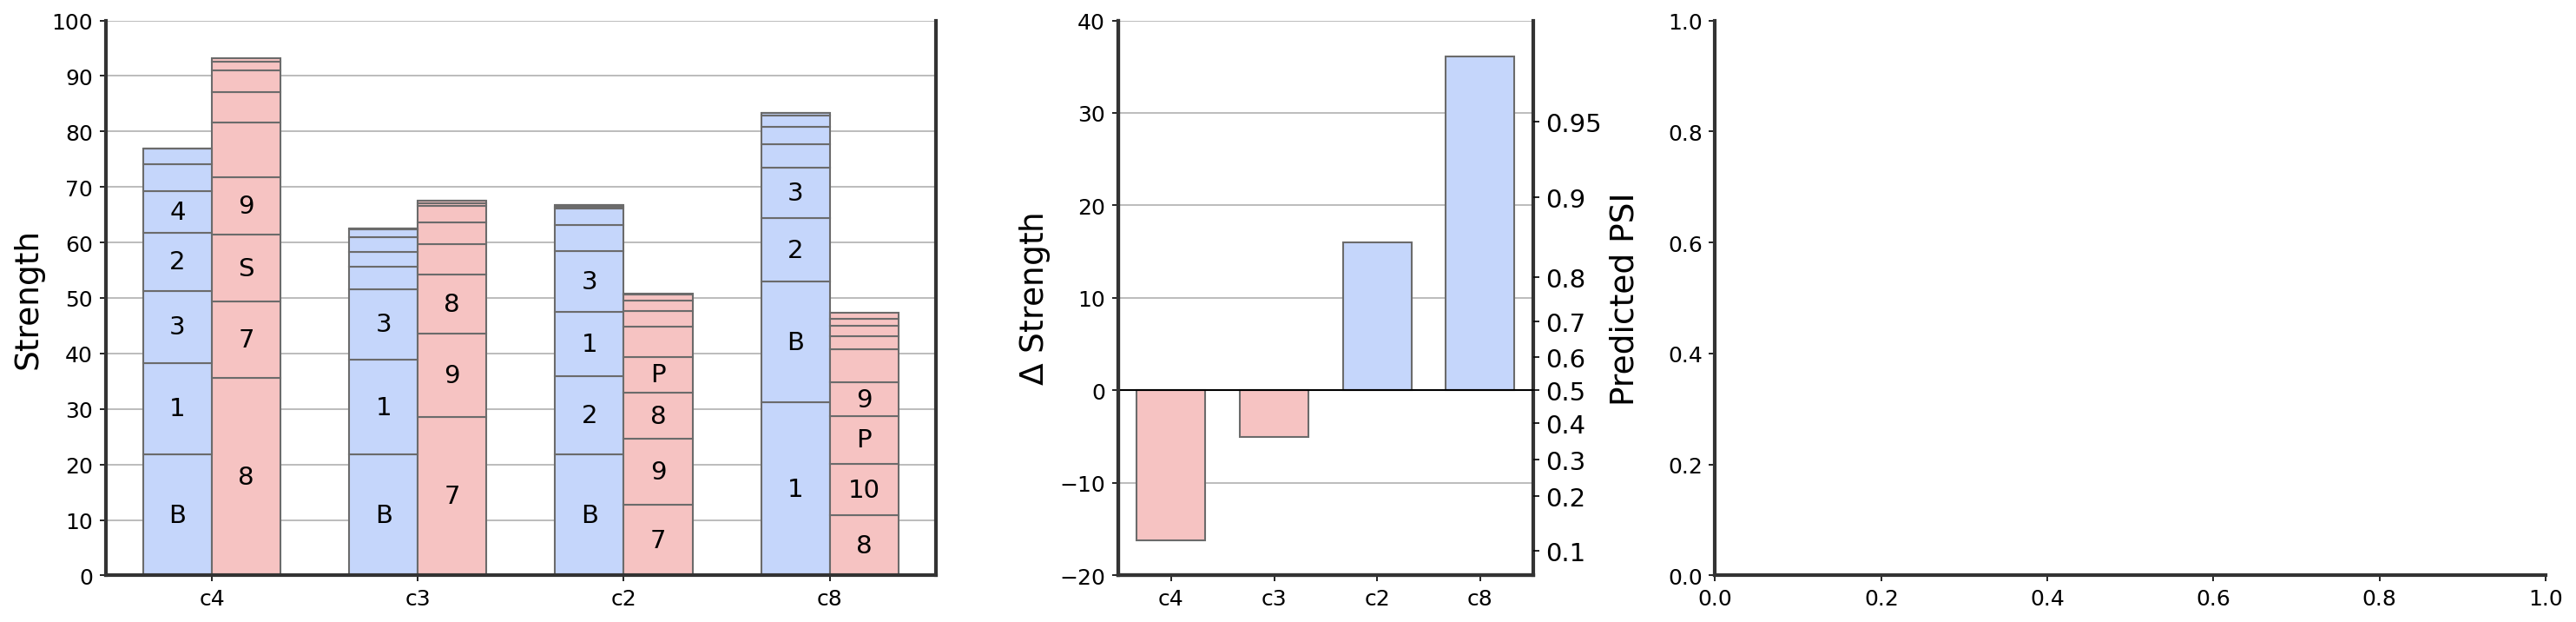

In [61]:
axarr, fig = draw_force_plot(structure_incl_act, structure_skip_act,
                             annotations,
                             seq_filters_grouping, struct_filters_grouping,
                             num_seq_filters, link_midpoint, highlight_forces,
                             incl_color, skip_color, light_incl_color, light_skip_color,
                             delta_force_y_range=(-20, 40), force_y_range=(0, 100),
                             draw_numbers=True, numbers_min_bar_height=6
                            )

# fig.savefig('./figs/c4c3c2c8.svg',
#             transparent=True, pad_inches=0.1,
#     bbox_inches='tight')
# fig.savefig('./figs/c4c3c2c8.pdf',
#             transparent=True, pad_inches=0.1,
#     bbox_inches='tight')

## porgs 1, 3, 6

In [62]:
porg_exon_sets = [
    [
        'AGTTTTACGAGAACCCCGTCACACCTAAATTCGCTTAACCTCCAACCAACAGTAAACACCGCTTACTACA',
        'AGTTTTACGAGAACCCCGTCACACCTAAATTCGGTTAACCTCCAACCAACAGTAAACACCGCTTACTACA',
    ],
    [
        'CTCCCAGTCACACGCAGTCTCCGCCTAACTTCATAGTCTCATGTCATATCTTCTTAAGCTGCCGTGCCAC',
        'CTCCCAGTCACACGCAGTCTCCGCCTAACTTCATAGTCTCATGTGATATCTTCTTAAGCTGCCGTGCCAC',
    ],
    [
        'TCGAGCCATTGGGGGCCAACGCATCGCCCATATCACCGAATCCTTCTTATTCAGACATTTACTACGGCCC',
        'TCGAGCCATTGGGGGCCAACGCATCGCCCATATCACCGAATCCTTCTTATTCAGAGATTTACTACGGCCC'
    ]
]
annotation_sets = [['O', 'G']] * 3
filename_prefixes = ['porg1', 'porg3', 'porg6']

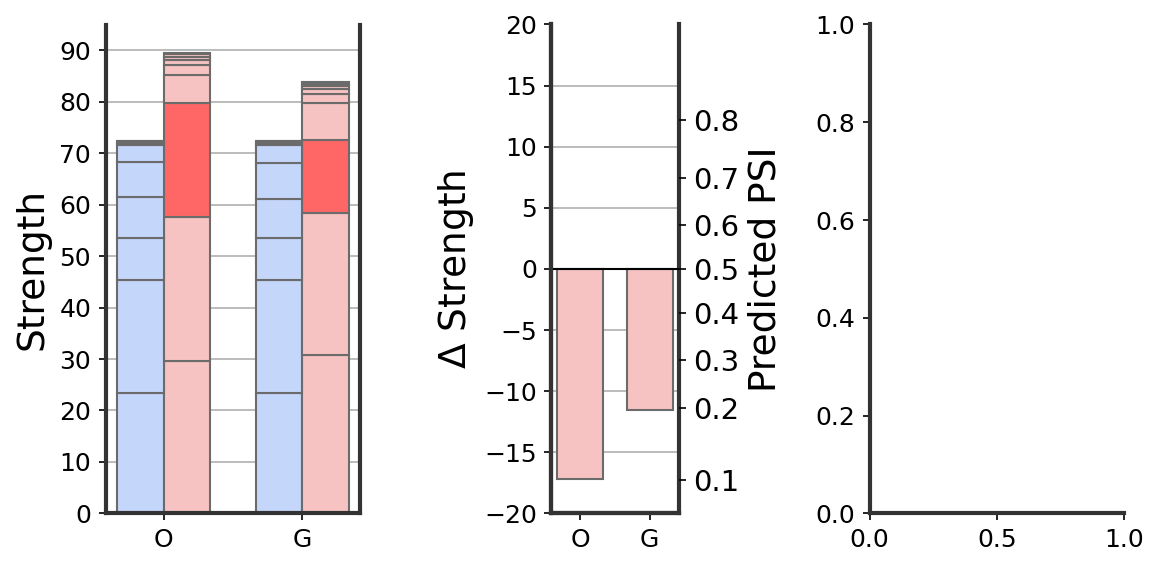

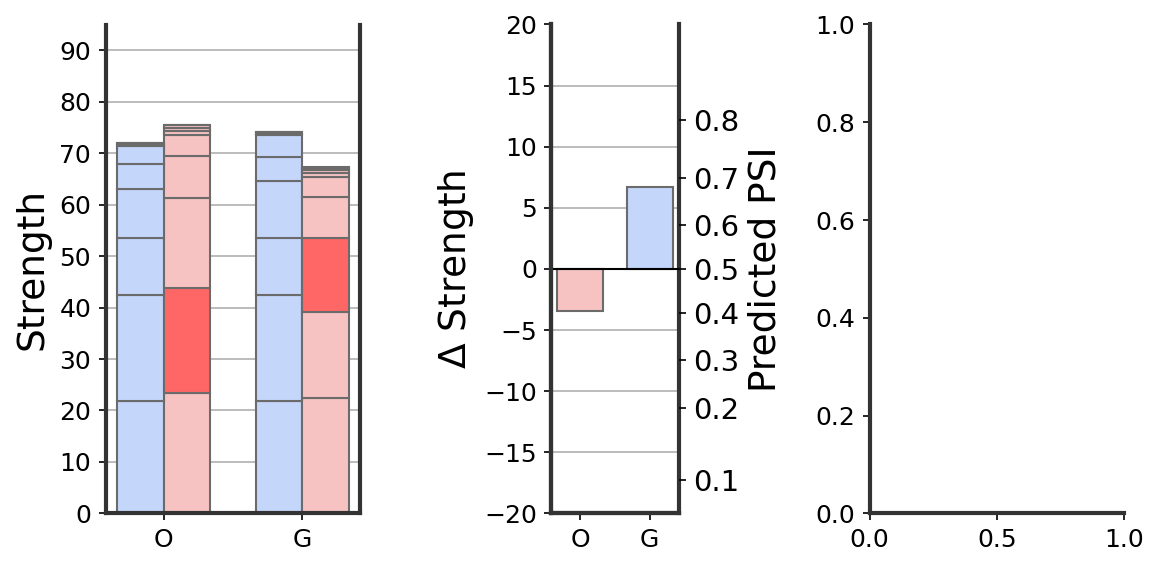

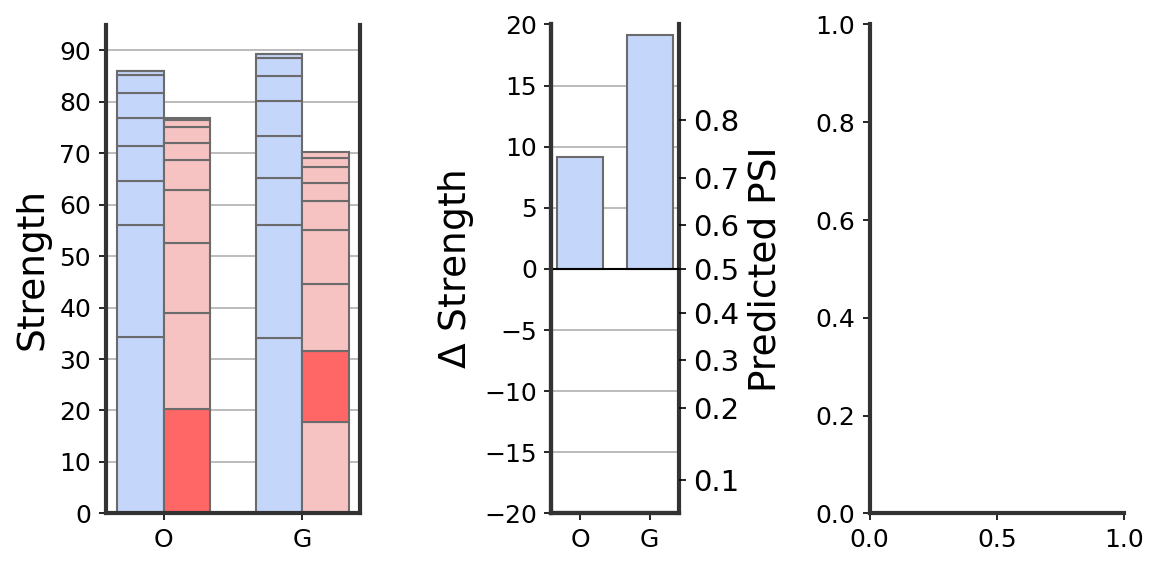

In [63]:
for porg_exons, annotations, filename_prefix in zip(porg_exon_sets, annotation_sets, filename_prefixes):
    porg_sequences = [
        figutils.add_flanking(e, 10) for e in porg_exons
    ]
    porg_data = figutils.create_input_data(porg_sequences)
    porg_incl_act, porg_skip_act = structure_out_model.predict(porg_data)

    highlight_forces = ['skip_struct_1']

    axarr, fig = draw_force_plot(porg_incl_act, porg_skip_act,
                                 annotations,
                                 seq_filters_grouping, struct_filters_grouping,
                                 num_seq_filters, link_midpoint, highlight_forces,
                                 incl_color, skip_color, light_incl_color, light_skip_color, figsize=(8, 4), 
                                 delta_force_y_range=(-20, 20), force_y_range=(0, 95),
                                 ys=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
                                )
#     fig.savefig(f'./figs/{filename_prefix}.svg',
#                 transparent=True, pad_inches=0.1,
#         bbox_inches='tight')
#     fig.savefig(f'./figs/{filename_prefix}.pdf',
#                 transparent=True, pad_inches=0.1,
#         bbox_inches='tight')
    plt.show()

## structure sequences 4, 5, 6

In [64]:
structure_exon_sets = [
    [
        'TCGCTCTCTAAAAAAGTCACCTACTTAACACGACGTGCCTCCGTGGCACGAAAATAAACCACTAAGAAAA',
        'TCGCTCTCTAAAAAAGTCACCTACTTAACACGACGGGCCTCCGTGGCACGAAAATAAACCACTAAGAAAA',
        'TCGCTCTCTAAAAAAGTCACCTACTTAACACGACGTGCCTCCGTGGCCCGAAAATAAACCACTAAGAAAA',
        'TCGCTCTCTAAAAAAGTCACCTACTTAACACGACGGGCCTCCGTGGCCCGAAAATAAACCACTAAGAAAA',
    ], [
        'TCTGCCCCTACACACAGGCACCTCGGCGATCGCCCGGGACACATCCGGGCCCTTGTTTCTATTCCGCCTC',
        'TCTGCCCCTACACACAGGCACCTCGGCGATCGCCAGGGACACATCCGGGCCCTTGTTTCTATTCCGCCTC',
        'TCTGCCCCTACACACAGGCACCTCGGCGATCGCCCGGGACACATCCTGGCCCTTGTTTCTATTCCGCCTC',
        'TCTGCCCCTACACACAGGCACCTCGGCGATCGCCAGGGACACATCCTGGCCCTTGTTTCTATTCCGCCTC',
    ], [
        'ACGGAACCGCCTGTCGGTTCCCACCCGTCTACCATGCACATACTCCTCTTTTTTGACCCGAAAACCTCCA',
        'ACGGACCCGCCTGTCGGTTCCCACCCGTCTACCATGCACATACTCCTCTTTTTTGACCCGAAAACCTCCA',
        'ACGGAACCGCCTGTCGGGTCCCACCCGTCTACCATGCACATACTCCTCTTTTTTGACCCGAAAACCTCCA',
        'ACGGACCCGCCTGTCGGGTCCCACCCGTCTACCATGCACATACTCCTCTTTTTTGACCCGAAAACCTCCA'
    ]
]
annotation_sets = [['O', 'D', 'U', 'B']] * 3
filename_prefixes = ['2c4', '2c5', '2c6']

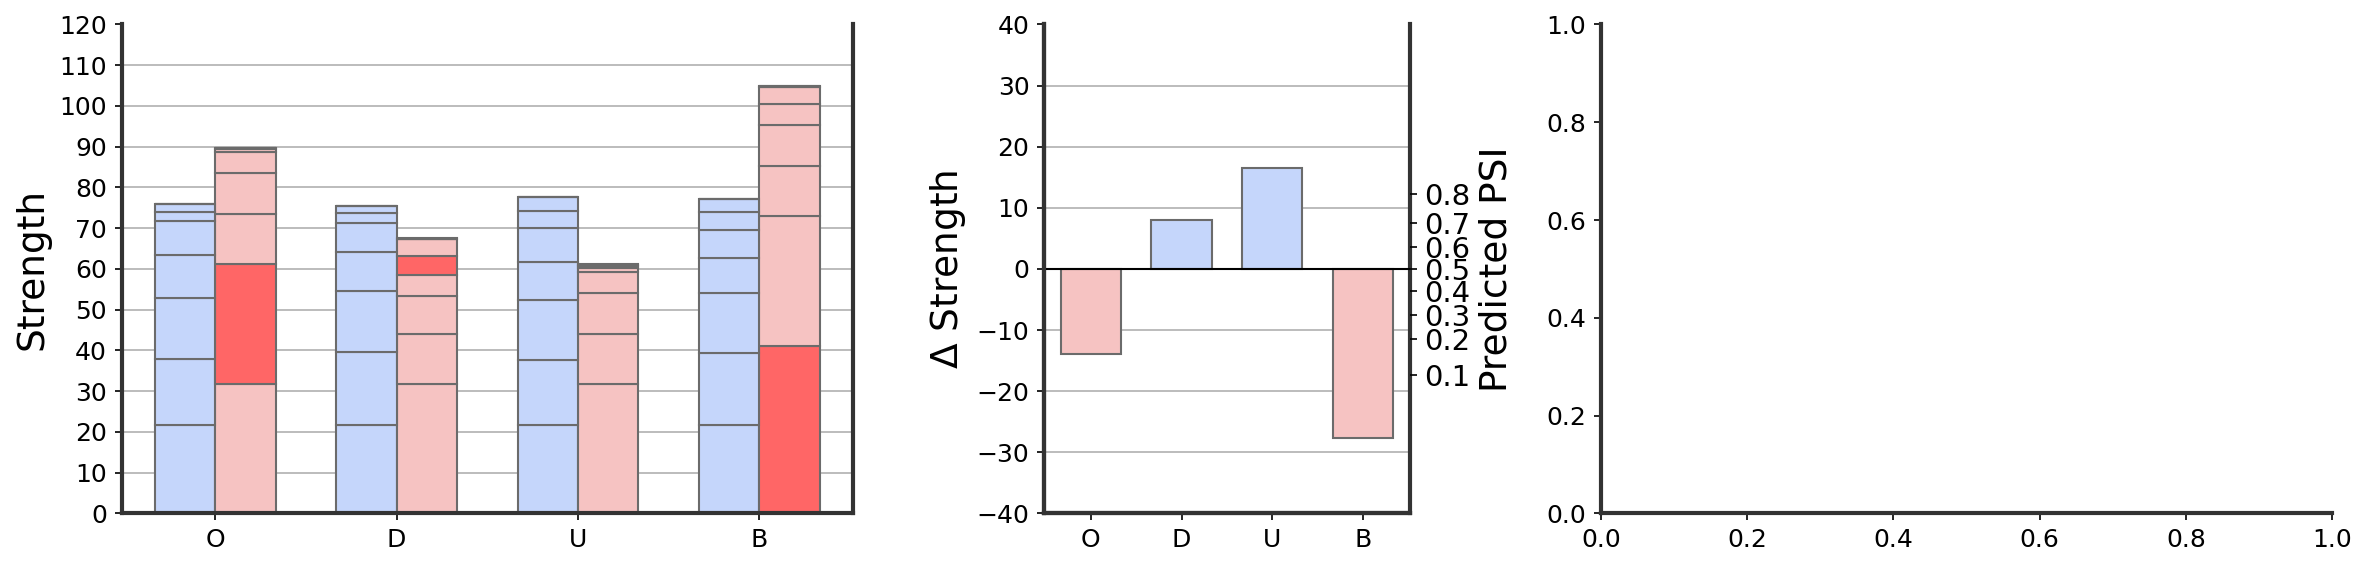

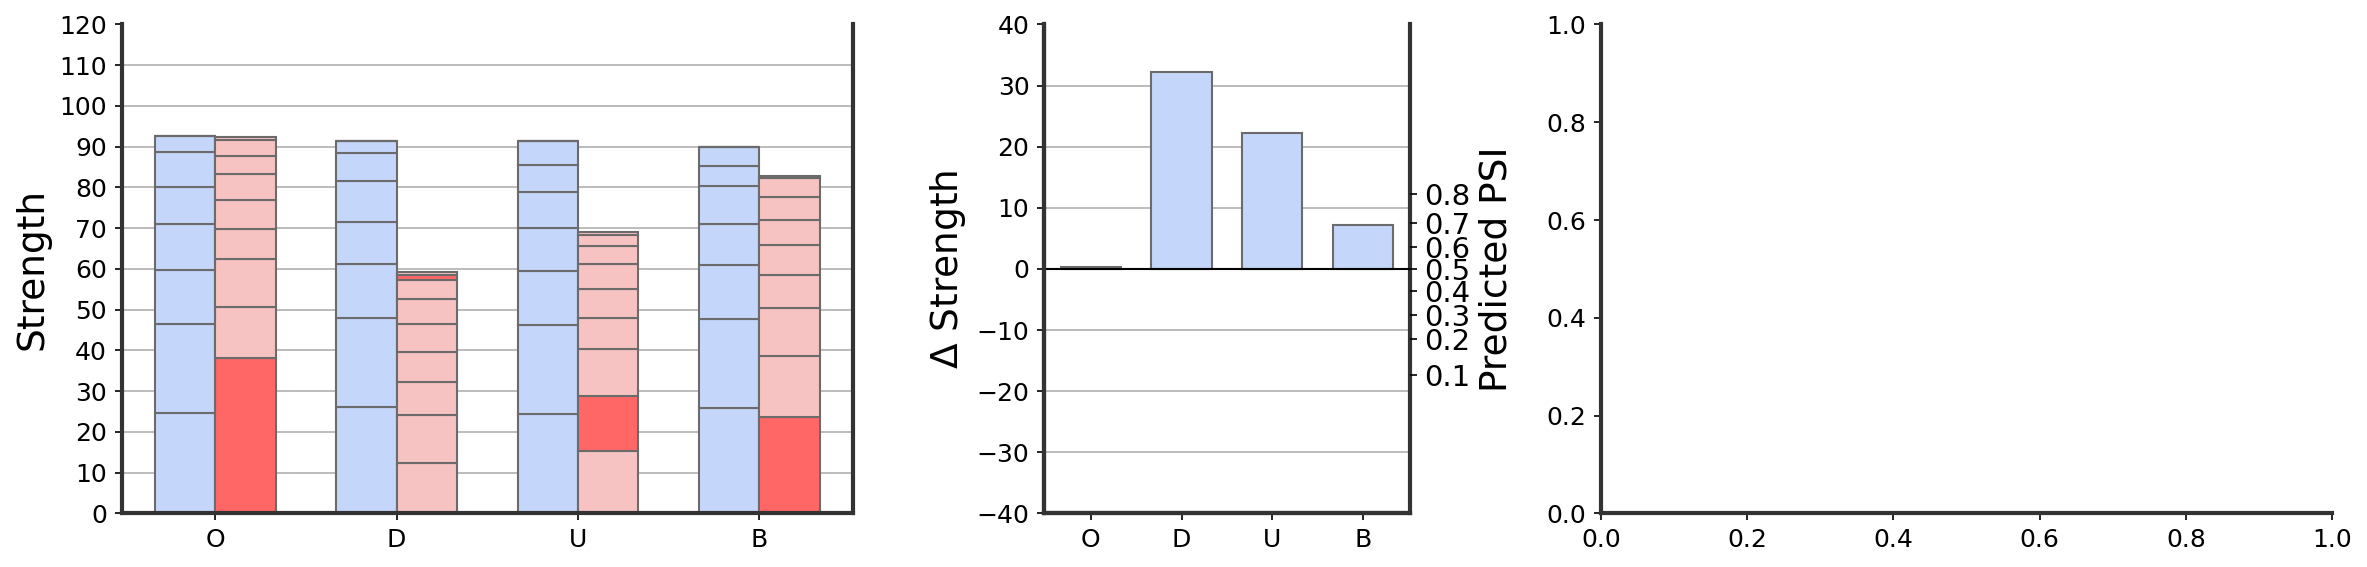

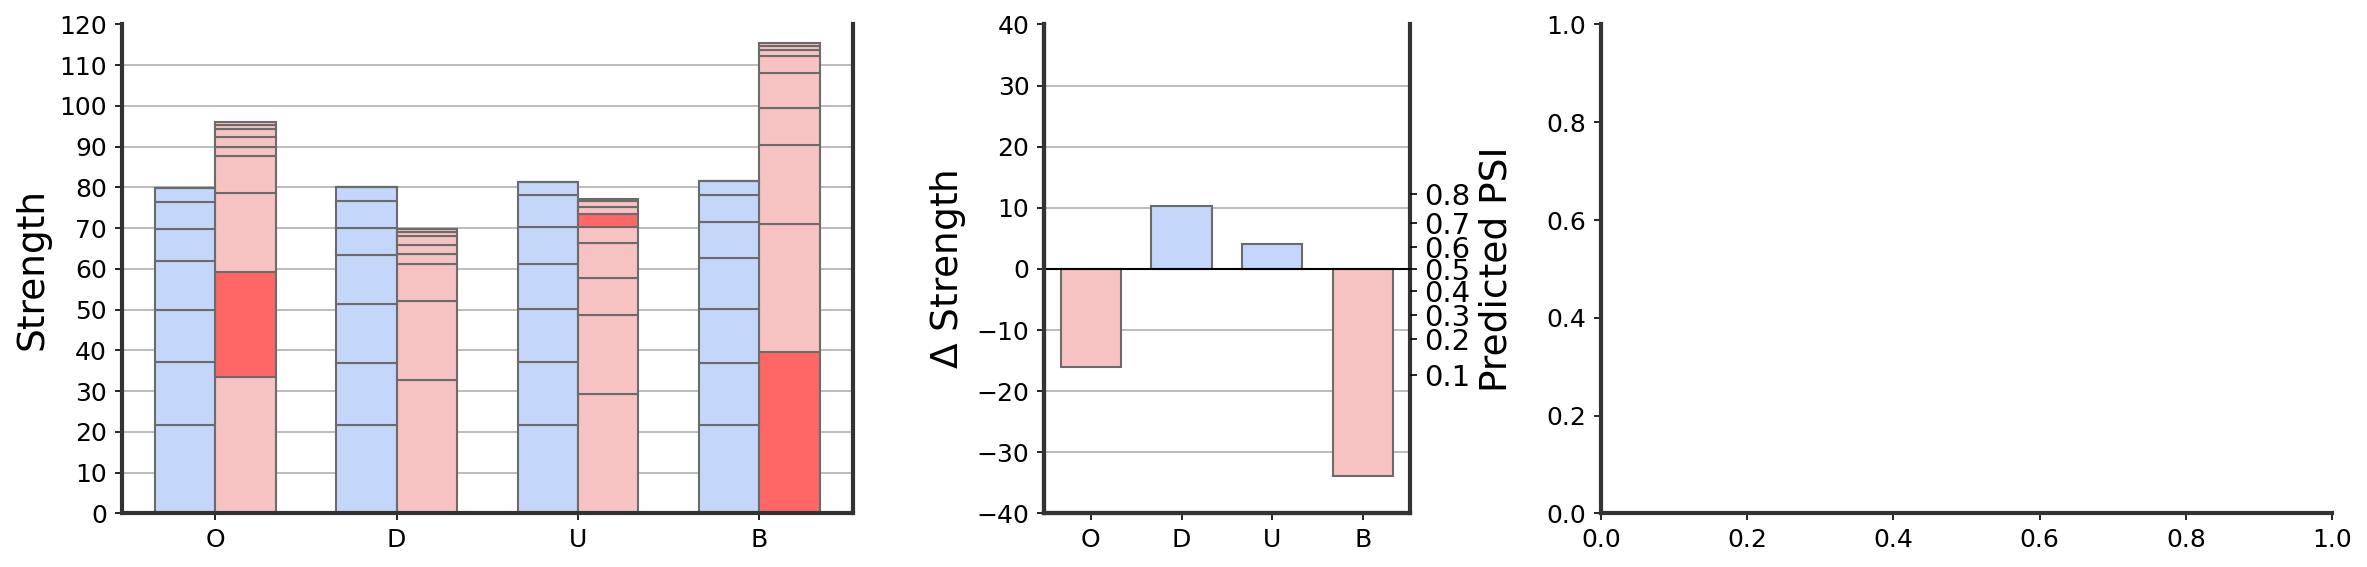

In [65]:
for structure_exons, annotations, filename_prefix in zip(structure_exon_sets, annotation_sets, filename_prefixes):
    structure_sequences = [
        figutils.add_flanking(e, 10) for e in structure_exons
    ]
    structure_data = figutils.create_input_data(structure_sequences)
    structure_incl_act, structure_skip_act = structure_out_model.predict(
        structure_data)

    highlight_forces = ['skip_struct_0_2_3']

    axarr, fig = draw_force_plot(structure_incl_act, structure_skip_act,
                                 annotations,
                                 seq_filters_grouping, struct_filters_grouping,
                                 num_seq_filters, link_midpoint, highlight_forces,
                                 incl_color, skip_color, light_incl_color, light_skip_color, figsize=(16, 4),
                                 delta_force_y_range=(-40, 40), force_y_range=(0, 120),
                                 ys=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
                                )
#     fig.savefig(f'./figs/{filename_prefix}.svg',
#                 transparent=True, pad_inches=0.1,
#         bbox_inches='tight')
#     fig.savefig(f'./figs/{filename_prefix}.pdf',
#                 transparent=True, pad_inches=0.1,
#         bbox_inches='tight')
    plt.show()

### Location-specific barplot

In [66]:
incl_skip_exons = ['GCCCGAAAGCTCCCTACTGCAGTTTACGACCCTTAAGGCTTGGGTGCTCTTACGCGCTGATCGATATAAG',
'TCGCACCGCAGGTTCGGTTTTTTGGTATAATACGCGGCACTCCAAAATTACTCTGGGGCACCCTCACCAG']
annotations = ['E1', 'E2']

incl_skip_sequences = [
    figutils.add_flanking(e, 10).replace('T', 'U') for e in incl_skip_exons
]
incl_skip_data = figutils.create_input_data(incl_skip_sequences)
incl_skip_incl_act, incl_skip_skip_act = structure_out_model.predict(incl_skip_data)
highlight_forces = []

In [67]:
incl_forces, skip_forces = force.create_force_data(incl_skip_incl_act[0], incl_skip_skip_act[0],
                                                   seq_filters_grouping, struct_filters_grouping,
                                                   num_seq_filters, sum_positions=False, link_midpoint=link_midpoint)


In [68]:
seq = incl_skip_sequences[0]

In [69]:
def extract_pos(key):
    force_key, pos_key = key.split('__')
    return force_key, int(pos_key.split('_')[-1])

In [70]:
top_k = 10

In [71]:
incl_force_by_pos = defaultdict(lambda: defaultdict(lambda: 0))

l = [ee for ee in incl_forces.sort_values(ascending=False).index[:top_k] if 'pos_' in ee]
for e in l:
    key, pos = extract_pos(e)
    for i in range(90):
        incl_force_by_pos[key][i] = 0
        
for e in l:
    key, pos = extract_pos(e)
    incl_force_by_pos[key][pos] += incl_forces[e]
    
incl_force_by_pos = pd.DataFrame(incl_force_by_pos)

In [72]:
skip_force_by_pos = defaultdict(lambda: defaultdict(lambda: 0))

l = [ee for ee in skip_forces.sort_values(ascending=False).index[:top_k] if 'pos_' in ee]
for e in l:
    key, pos = extract_pos(e)
    for i in range(90):
        skip_force_by_pos[key][i] = 0
        
for e in l:
    key, pos = extract_pos(e)
    skip_force_by_pos[key][pos] += skip_forces[e]
    
skip_force_by_pos = pd.DataFrame(skip_force_by_pos)

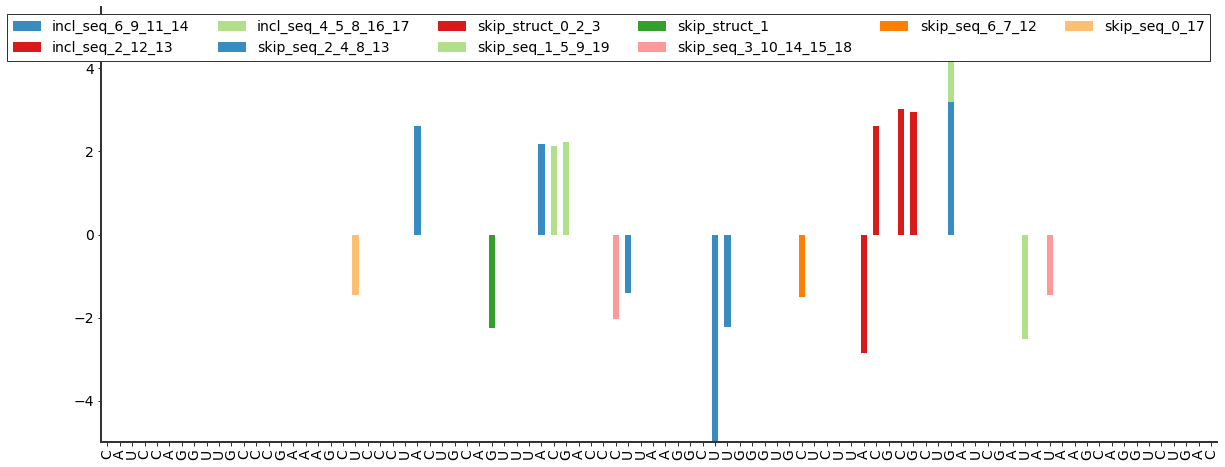

In [73]:
fig, ax = plt.subplots(figsize=(20, 8))
incl_force_by_pos.sort_index().plot(kind='bar', stacked=True, ax=ax)
(-skip_force_by_pos).sort_index().plot(kind='bar', stacked=True, ax=ax)
ax.set_xticks(range(90))
ax.set_xticklabels(list(seq))
ax.legend(ncol=6)
plt.show()